# cleaning of Fake.csv

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Tejas
[nltk_data]     Rawool\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Load Fake.csv
fake_df = pd.read_csv("Fake.csv")


In [4]:
# Add label (0 for Fake)
fake_df['label'] = 0


In [5]:
# Keep only text and label
fake_df = fake_df[['text', 'label']]


In [6]:
# Remove missing values
fake_df.dropna(inplace=True)


In [7]:
# Initialize stemmer and stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))


In [8]:
# Cleaning function (MATCHING TRUE.CSV)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

In [9]:
# Apply cleaning
fake_df['text'] = fake_df['text'].apply(clean_text)


In [10]:
# Save cleaned file
fake_df.to_csv("clean_Fake.csv", index=False)


In [11]:
print("Fake.csv cleaned successfully!")

Fake.csv cleaned successfully!


# cleaning of True.csv

In [12]:
#Load Dataset
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Tejas
[nltk_data]     Rawool\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
true_df = pd.read_csv("True.csv")

In [14]:
#Add Label (1 for Real News)
true_df['label'] = 1


In [15]:
#Keep Only Required Columns
true_df = true_df[['text', 'label']]


In [16]:
#Remove Missing Values
true_df.dropna(inplace=True)


In [17]:
#Define Standard Cleaning Function
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove numbers and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords and apply stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    return ' '.join(words)


In [18]:
#Apply Cleaning
true_df['text'] = true_df['text'].apply(clean_text)


In [19]:
#Save Cleaned File
true_df.to_csv("clean_True.csv", index=False)
print("True.csv cleaned successfully!")


True.csv cleaned successfully!


# MERGE BOTH DATASETS

In [20]:
true_df = pd.read_csv("clean_True.csv")
fake_df = pd.read_csv("clean_Fake.csv")

print(true_df.shape)
print(fake_df.shape)

(21417, 2)
(23481, 2)


In [21]:
#Merge the Datasets
data = pd.concat([true_df, fake_df], axis=0)


In [22]:
#Shuffle the Dataset
data = data.sample(frac=1, random_state=42).reset_index(drop=True)


In [23]:
print(data.head())
print(data['label'].value_counts())


                                                text  label
0  donald trump white hous chao tri cover russia ...      0
1  donald trump presumpt gop nomine time rememb c...      0
2  mike penc huge homophob support exgay convers ...      0
3  san francisco reuter california attorney gener...      1
4  twist reason come pelosi day especi promin dem...      0
label
0    23481
1    21417
Name: count, dtype: int64


# TF-IDF + TRAIN TEST SPLIT

In [24]:
# Make sure no missing values exist
data['text'] = data['text'].fillna('')


In [25]:
# Ensure text column is string
data['text'] = data['text'].astype(str)

In [26]:
print(data['text'].isnull().sum())        # Check NaN count
print((data['text'] == '').sum())         # Check empty strings
print(data['text'].dtype)                 # Check datatype


0
716
str


In [27]:
# Remove rows where text is NaN
data = data.dropna(subset=['text'])

# Convert everything to string
data['text'] = data['text'].astype(str)

# Remove rows that are empty after cleaning
data = data[data['text'].str.strip() != '']

print("After cleaning:")
print(data['text'].isnull().sum())
print((data['text'] == '').sum())


After cleaning:
0
0


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = data['text']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# FINAL SAFETY FIX
X_train = X_train.fillna('')
X_test = X_test.fillna('')

vectorizer = TfidfVectorizer(max_df=0.7)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print("TF-IDF Completed Successfully!")


TF-IDF Completed Successfully!


In [29]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (35345, 159678)
X_test shape: (8837, 159678)


In [30]:
print("First 10 feature names:")
print(vectorizer.get_feature_names_out()[:10])


First 10 feature names:
['aa' 'aaa' 'aaaaackkk' 'aaaahhhh' 'aaaarrgh'
 'aaainnertextreplacernrngquotnquotelsevar' 'aab' 'aaba' 'aabo' 'aaccord']


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


In [32]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print('Logistic Regression Accuracy:', round(accuracy_score(y_test, lr_pred), 4))
print('Logistic Regression Confusion Matrix:')
print(confusion_matrix(y_test, lr_pred))
print('Logistic Regression Classification Report:')
print(classification_report(y_test, lr_pred, digits=4))


Logistic Regression Accuracy: 0.9839
Logistic Regression Confusion Matrix:
[[4530   82]
 [  60 4165]]
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0     0.9869    0.9822    0.9846      4612
           1     0.9807    0.9858    0.9832      4225

    accuracy                         0.9839      8837
   macro avg     0.9838    0.9840    0.9839      8837
weighted avg     0.9839    0.9839    0.9839      8837



In [33]:
# Naive Bayes
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

print('Multinomial Naive Bayes Accuracy:', round(accuracy_score(y_test, nb_pred), 4))
print('Multinomial Naive Bayes Confusion Matrix:')
print(confusion_matrix(y_test, nb_pred))
print('Multinomial Naive Bayes Classification Report:')
print(classification_report(y_test, nb_pred, digits=4))


Multinomial Naive Bayes Accuracy: 0.9371
Multinomial Naive Bayes Confusion Matrix:
[[4292  320]
 [ 236 3989]]
Multinomial Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0     0.9479    0.9306    0.9392      4612
           1     0.9257    0.9441    0.9348      4225

    accuracy                         0.9371      8837
   macro avg     0.9368    0.9374    0.9370      8837
weighted avg     0.9373    0.9371    0.9371      8837



In [34]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Multinomial Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred)
    ]
})

comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison_df


,Model,Accuracy
0,Logistic Regression,0.983931
1,Multinomial Naive Bayes,0.937083


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

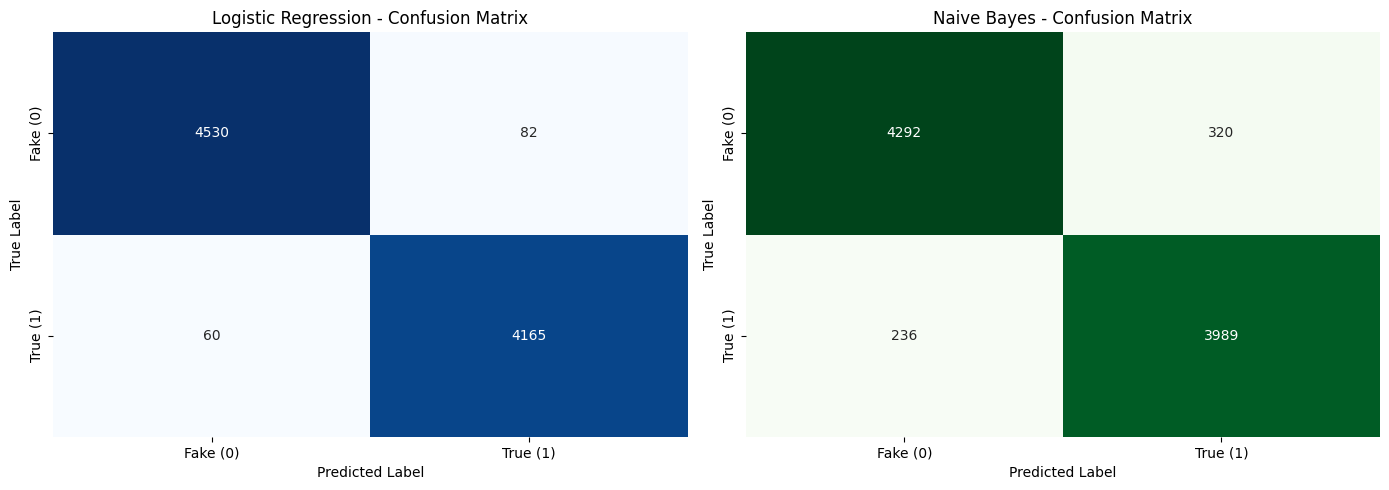

In [36]:
# Run this after you already have: y_test, lr_pred, nb_pred



labels = ['Fake (0)', 'True (1)']

cm_lr = confusion_matrix(y_test, lr_pred)
cm_nb = confusion_matrix(y_test, nb_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=labels, yticklabels=labels, ax=axes[0]
)
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(
    cm_nb, annot=True, fmt='d', cmap='Greens', cbar=False,
    xticklabels=labels, yticklabels=labels, ax=axes[1]
)
axes[1].set_title('Naive Bayes - Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


In [37]:
# SVM (LinearSVC)
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print('SVM Accuracy:', round(accuracy_score(y_test, svm_pred), 4))
print('SVM Confusion Matrix:')
print(confusion_matrix(y_test, svm_pred))
print('SVM Classification Report:')
print(classification_report(y_test, svm_pred, digits=4))


SVM Accuracy: 0.9954
SVM Confusion Matrix:
[[4591   21]
 [  20 4205]]
SVM Classification Report:
              precision    recall  f1-score   support

           0     0.9957    0.9954    0.9956      4612
           1     0.9950    0.9953    0.9951      4225

    accuracy                         0.9954      8837
   macro avg     0.9953    0.9954    0.9954      8837
weighted avg     0.9954    0.9954    0.9954      8837



In [38]:
# Detailed metrics for all models (one by one)
models_predictions = [
    ('Logistic Regression', lr_pred),
    ('Multinomial Naive Bayes', nb_pred),
    ('SVM (LinearSVC)', svm_pred)
]

avg = 'binary' if len(pd.Series(y_test).unique()) == 2 else 'weighted'

for model_name, pred in models_predictions:
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average=avg, zero_division=0)
    rec = recall_score(y_test, pred, average=avg, zero_division=0)
    f1 = f1_score(y_test, pred, average=avg, zero_division=0)

    print(f'\n{model_name}')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-Score : {f1:.4f}')

metrics_df = pd.DataFrame([
    {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average=avg, zero_division=0),
        'Recall': recall_score(y_test, pred, average=avg, zero_division=0),
        'F1-Score': f1_score(y_test, pred, average=avg, zero_division=0)
    }
    for model_name, pred in models_predictions
])

metrics_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)



Logistic Regression
Accuracy : 0.9839
Precision: 0.9807
Recall   : 0.9858
F1-Score : 0.9832

Multinomial Naive Bayes
Accuracy : 0.9371
Precision: 0.9257
Recall   : 0.9441
F1-Score : 0.9348

SVM (LinearSVC)
Accuracy : 0.9954
Precision: 0.9950
Recall   : 0.9953
F1-Score : 0.9951


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM (LinearSVC),0.995360,0.995031,0.995266,0.995149
1,Logistic Regression,0.983931,0.980692,0.985799,0.983239
2,Multinomial Naive Bayes,0.937083,0.925737,0.944142,0.934849


Confusion Matrix:
 [[4579   33]
 [  14 4211]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      4612
           1       0.99      1.00      0.99      4225

    accuracy                           0.99      8837
   macro avg       0.99      0.99      0.99      8837
weighted avg       0.99      0.99      0.99      8837



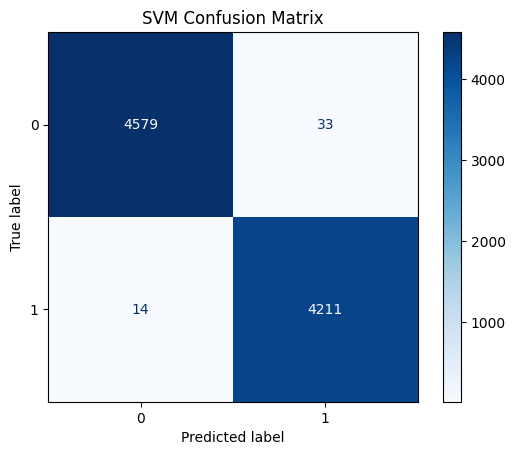

In [39]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Train SVM
svm_model = SVC(kernel='linear', random_state=42)   # change kernel if needed
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Optional: detailed metrics
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("SVM Confusion Matrix")
plt.show()


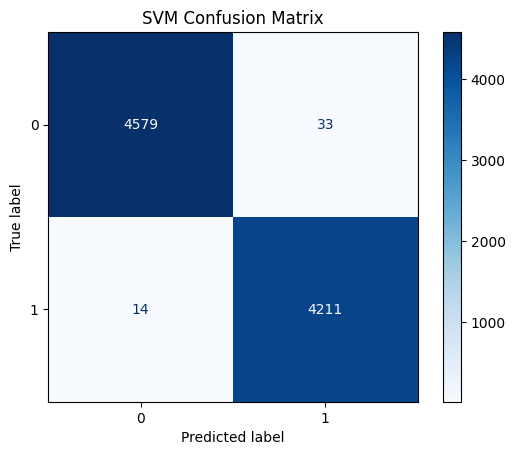

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test, cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

In [41]:
import joblib

# Save models
joblib.dump(lr_model, "logistic_regression_model.pkl")
joblib.dump(nb_model, "naive_bayes_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("All models and vectorizer saved successfully!")

All models and vectorizer saved successfully!


In [42]:
import joblib

# Load models
lr_model = joblib.load("logistic_regression_model.pkl")
nb_model = joblib.load("naive_bayes_model.pkl")
svm_model = joblib.load("svm_model.pkl")

# Load TF-IDF vectorizer
vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Models loaded successfully!")

Models loaded successfully!
